# Multiple Linear Regression

## 1. The Statsmodels Approach

Focus: Inference, Significance, and Causality.

In [28]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as stats

In [6]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [2]:
bs = pd.read_csv("Boston.csv")
display(bs.head(10))
display(bs.shape)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


(506, 13)

In [3]:
bs.describe().T

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


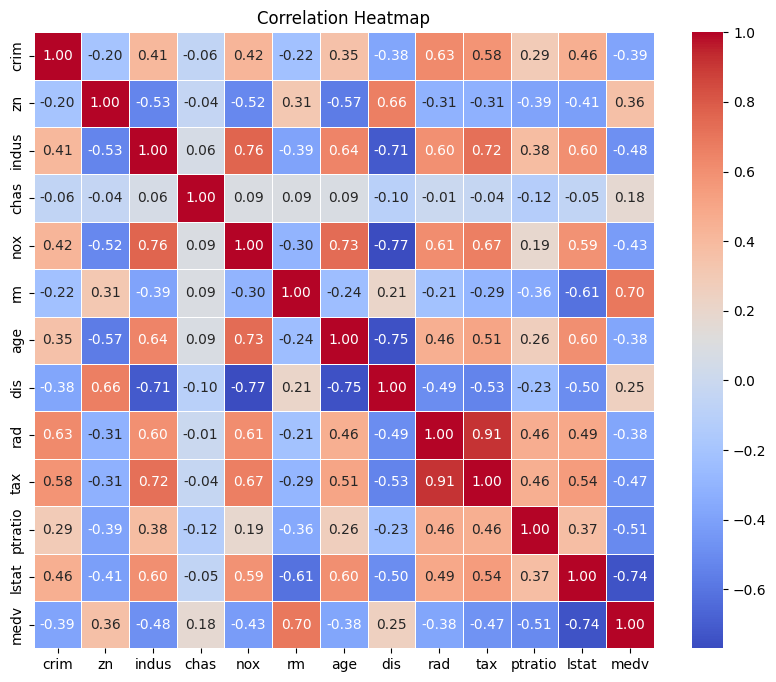

In [21]:
# 1. Calculate the correlations (only for numerical columns)
# .corr() calculates a score from -1 to 1 for every pair of columns
corr_matrix = bs.select_dtypes(include=['number']).corr()

# 2. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      # This puts the actual numbers inside the squares
            cmap='coolwarm', # The color scheme (red for positive, blue for negative)
            fmt='.2f',       # Limits the numbers to 2 decimal places
            linewidths=0.5,  # Adds a tiny gap between squares for readability
            ax=ax)           # Tells seaborn to draw on our 'ax' canvas

ax.set_title('Correlation Heatmap')
plt.show()

In [37]:
X = bs.drop(columns="medv")
y = bs["medv"]

# Statsmodels does not include an intercept by default #
X = sm.add_constant(X)

In [38]:
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Sat, 04 Apr 2026   Prob (F-statistic):          2.23e-133
Time:                        12:54:47   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.6173      4.936      8.431      0.000      31.919      51.316
crim          -0.1214      0.033     -3.678      0.000      -0.186      -0.057
zn             0.0470      0.014      3.384      0.001       0.020       0.074
indus          0.0135      0.062      0.217      0.829      -0.109       0.136
chas           2.8400      0.870      3.264      0.001       1.131       4.549
nox          -18.7580      3.851     -4.870      0.000     -26.325     -11.191
rm             3.6581      0.420      8.705      0.000       2.832       4.484
age            0.0036      0.013      0.271      0.787      -0.023       0.030
dis           -1.4908      0.202     -7.394      0.000      -1.887      -1.095
rad            0.2894      0.067      4.325      0.000       0.158       0.421
tax           -0.0127      0.004     -3.337      0.001      -0.020      -0.005
ptratio       -0.9375      0.132     -7.091      0.000      -1.197      -0.678
lstat         -0.5520      0.051    -10.897      0.000      -0.652      -0.452
==============================================================================
Omnibus:                      171.096   Durbin-Watson:                   1.077
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              709.937
Skew:                           1.477   Prob(JB):                    6.90e-155
Kurtosis:                       7.995   Cond. No.                     1.17e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.17e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Clearly Significant Variables (p < 0.05)**
- crim (-) → higher crime → lower prices
- zn (+) → more residential zoning → higher prices
- chas (+) → proximity to river increases value
- nox (-) → pollution strongly decreases value
- rm (+) → more rooms → higher value (very strong effect)
- dis (-) → farther from employment centers → lower value
- rad (+) → accessibility to highways increases value
- tax (-) → higher taxes reduce value
- ptratio (-) → worse student-teacher ratio lowers value
- lstat (-) → strong negative socioeconomic effect

---

**Residual Diagnostics**

*(a) Normality*
- Jarque–Bera p ≈ 0 → reject normality
- Skew = 1.48 → strong right skew
- Kurtosis = 7.99 → heavy tails

Your QQ plot confirms this:
- Clear deviation from straight line
- Extreme residuals present

*(b) Autocorrelation*
- Durbin–Watson = 1.077
- ≈ 2 → no autocorrelation
- < 2 → positive autocorrelation in residuals

*(c) Condition Number*
- Cond. No. = 1.17e+04 → VERY high
- Multicollinearity and/or scaling issues

In [36]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [VIF(X.values, i) for i in range(X.shape[1])]

display(vif_data.sort_values(by='VIF', ascending=False))

,feature,VIF
0,const,535.526619
10,tax,9.002158
9,rad,7.445301
5,nox,4.369093
3,indus,3.987181
8,dis,3.954037
7,age,3.088232
12,lstat,2.870777
2,zn,2.298459
6,rm,1.912532


**Multicollinearity (Critical Issue)**
- tax ≈ 9 → high
- rad ≈ 7.4 → high
- nox, indus, dis ≈ 3–4 → moderate

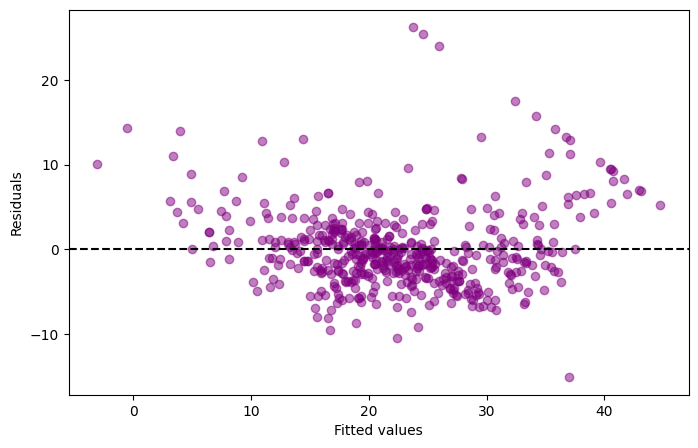

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(model.fittedvalues, model.resid, color='purple', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

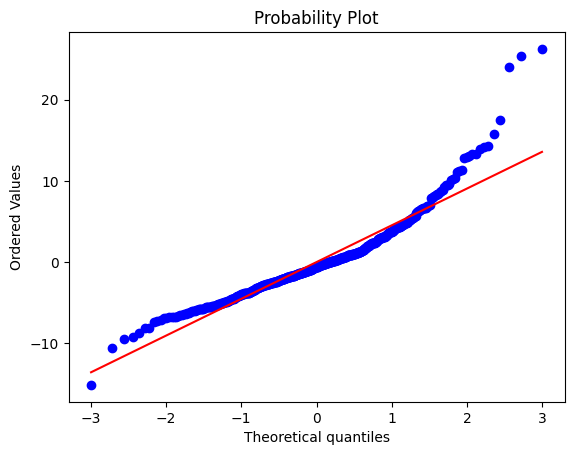

In [35]:
stats.probplot(model.resid, dist="norm", plot=plt)
plt.show()

## Model Improvements

While the model explains a substantial proportion of variance, diagnostic tests reveal violations of key OLS assumptions, particularly normality and multicollinearity. This suggests that although the model is useful for inference, it requires refinement through variable selection and nonlinear transformations.

1. Remove insignificant variables
2. Address Multicollinearity
3. Add Non-Linearity
4. Transform Skewed Variables

In [39]:
# Copy Dataset
df_ref = bs.copy()

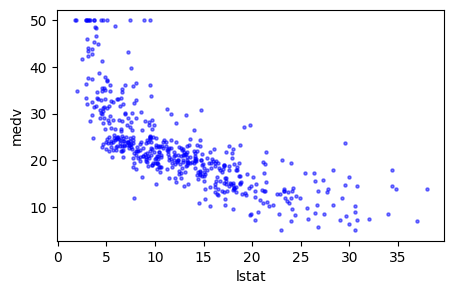

In [57]:
fig, ax = plt.subplots(figsize=(5, 3))
plt.scatter(df_ref["lstat"], df_ref["medv"], color='blue', s = 5, alpha = 0.5)
plt.xlabel("lstat")
plt.ylabel("medv")
plt.show()

In [41]:
# --- 3. Feature Engineering ---
# Add nonlinear term to capture curvature in lstat relationship
df_ref["lstat_sq"] = df_ref["lstat"] ** 2

# Log-transform skewed variable (crime rate is highly skewed)
df_ref["log_crim"] = np.log(df_ref["crim"])

# --- 4. Feature Selection ---
# Remove:
# - insignificant variables: indus, age
# - multicollinearity driver: tax (we keep rad instead)

features = [
    "log_crim",   # transformed version of crim
    "zn",
    "chas",
    "nox",
    "rm",
    "dis",
    "rad",
    "ptratio",
    "lstat",
    "lstat_sq"   # nonlinear term
]

# --- 5. Define X (predictors) and y (target) ---
X = df_ref[features]
y = df_ref["medv"]

# --- 6. Add intercept (required for statsmodels) ---
X = sm.add_constant(X)

# --- 7. Fit the refined OLS model ---
model_ref = sm.OLS(y, X).fit()

# Display full regression summary
display(model_ref.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     161.1
Date:                Sat, 04 Apr 2026   Prob (F-statistic):          1.34e-148
Time:                        13:01:10   Log-Likelihood:                -1473.9
No. Observations:                 506   AIC:                             2970.
Df Residuals:                     495   BIC:                             3016.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.7087      4.747      9.418      0.000      35.382      54.036
log_crim       0.0470      0.257      0.183      0.855      -0.458       0.552
zn             0.0094      0.013      0.710      0.478      -0.017       0.035
chas           3.1884      0.807      3.951      0.000       1.603       4.774
nox          -15.9700      3.506     -4.555      0.000     -22.858      -9.082
rm             3.2988      0.386      8.537      0.000       2.540       4.058
dis           -1.2260      0.176     -6.973      0.000      -1.571      -0.881
rad            0.0195      0.051      0.385      0.700      -0.080       0.119
ptratio       -0.8167      0.123     -6.652      0.000      -1.058      -0.575
lstat         -1.7042      0.124    -13.791      0.000      -1.947      -1.461
lstat_sq       0.0320      0.003      9.655      0.000       0.026       0.039
==============================================================================
Omnibus:                      122.650   Durbin-Watson:                   1.104
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              507.918
Skew:                           1.027   Prob(JB):                    5.09e-111
Kurtosis:                       7.458   Cond. No.                     8.48e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.48e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


VIF Scores:


,feature,VIF
0,const,562.101014
1,log_crim,7.691444
2,zn,2.364224
3,chas,1.045894
4,nox,4.108395
5,rm,1.834959
6,dis,3.411766
7,rad,4.816797
8,ptratio,1.758686
9,lstat,19.383716


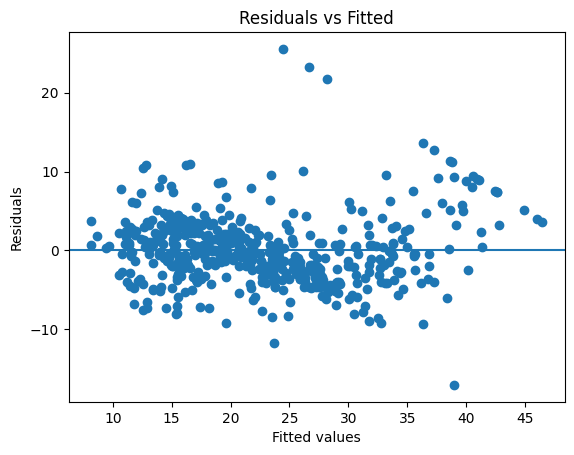

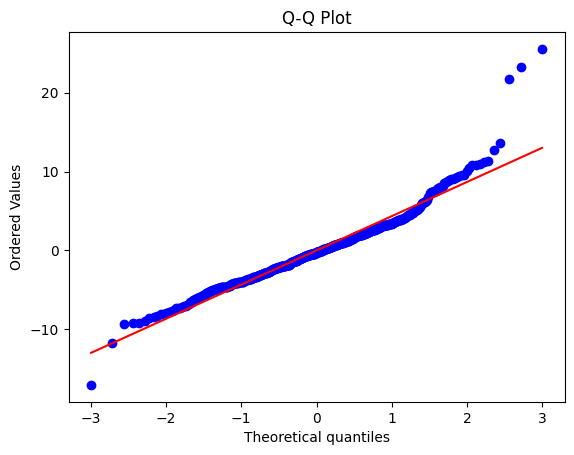


Model Comparison:
Original AIC: 3035.8206794796506
Refined AIC: 2969.891424513317
Original BIC: 3090.765656180388
Refined BIC: 3016.383327875479


In [43]:
# ================================
# 8. MULTICOLLINEARITY CHECK (VIF)
# ================================

# Compute Variance Inflation Factor for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [VIF(X.values, i) for i in range(X.shape[1])]

print("\nVIF Scores:")
display(vif_data)

# ================================
# 9. RESIDUAL DIAGNOSTICS
# ================================

# --- (a) Residuals vs Fitted ---
# Checks linearity and homoskedasticity
plt.scatter(model_ref.fittedvalues, model_ref.resid)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# --- (b) Q-Q Plot ---
# Checks normality of residuals
stats.probplot(model_ref.resid, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

# ================================
# 10. MODEL COMPARISON
# ================================

# Compare refined model with original model (assumes 'model' exists)
print("\nModel Comparison:")
print("Original AIC:", model.aic)
print("Refined AIC:", model_ref.aic)

print("Original BIC:", model.bic)
print("Refined BIC:", model_ref.bic)

## 2. Scikit Learn - Predictions

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [59]:
df_sl = bs.copy()

# Features and target
X = df_sl.drop('medv', axis=1)
y = df_sl['medv']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [61]:
# Create model
lr_model = LinearRegression()

# Train model on the training set
lr_model.fit(X_train, y_train)

LinearRegression()

In [62]:
y_pred = lr_model.predict(X_test)

In [63]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 22.78
R-squared: 0.69


In [71]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
5,rm,4.336902
3,chas,3.320226
8,rad,0.079384
1,zn,0.018890
6,age,-0.003373
2,indus,-0.045229
0,crim,-0.126578
10,lstat,-0.534465
9,ptratio,-0.924825
7,dis,-1.439985


In [72]:
# Create a comparison table
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Add a column for the specific error (Residual)
comparison_df['Error'] = comparison_df['Actual'] - comparison_df['Predicted']

display(comparison_df.head(10))

,Actual,Predicted,Error
173,23.6,29.120866,-5.520866
274,32.4,35.846651,-3.446651
491,13.6,17.186361,-3.586361
72,22.8,25.017880,-2.217880
452,16.1,17.571017,-1.471017
76,20.0,24.037939,-4.037939
316,17.8,17.340359,0.459641
140,14.0,14.080440,-0.080440
471,19.6,22.207326,-2.607326
500,16.8,20.789140,-3.989140


## 3. Annex - Can we improve our prediction model?

This block anticipates theoretical concepts that will follow in later chapters

In [75]:
# ------------------------------
# Option 1: Linear + Ridge
# ------------------------------

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
bs = pd.read_csv("Boston.csv")
X = bs.drop('medv', axis=1)
y = bs['medv']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Predict
y_pred = ridge.predict(X_test_scaled)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Option 1: Linear + Ridge")
print(f"MSE: {mse:.2f}, R²: {r2:.2f}")

Option 1: Linear + Ridge
MSE: 22.81, R²: 0.69


In [78]:
# ------------------------------
# Option 2: Linear + Polynomial + Ridge
# ------------------------------

from sklearn.preprocessing import PolynomialFeatures

# Polynomial expansion (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Train Ridge on expanded features
ridge_poly = Ridge(alpha=1.0)
ridge_poly.fit(X_train_poly, y_train)

# Predict
y_pred_poly = ridge_poly.predict(X_test_poly)

# Evaluate
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print("Option 2: Linear + Polynomial + Ridge")
print(f"MSE: {mse_poly:.2f}, R²: {r2_poly:.2f}")

Option 2: Linear + Polynomial + Ridge
MSE: 13.84, R²: 0.81


In [79]:
# ------------------------------
# Option 3: Random Forest Regressor
# ------------------------------

from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest
rf = RandomForestRegressor(
    n_estimators=200,   # number of trees
    max_depth=None,     # let trees grow fully
    random_state=42
)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Option 3: Random Forest Regressor")
print(f"MSE: {mse_rf:.2f}, R²: {r2_rf:.2f}")

Option 3: Random Forest Regressor
MSE: 8.76, R²: 0.88


## Explanatory Overview of Modeling Approaches on the Boston Housing Dataset

The goal of this analysis was to **predict median house values (`medv`)** using the Boston dataset. Three modeling strategies were explored, ranging from simple linear regression with regularization to more flexible models capturing non-linear relationships.

---

### Option 1: Linear Regression with Ridge Regularization

**Description:**

- Ridge regression is an extension of ordinary linear regression that adds **L2 regularization** to the loss function:

$$
\text{Loss} = \sum_i (y_i - \hat{y}_i)^2 + \alpha \sum_j \beta_j^2
$$

- The L2 penalty shrinks coefficient magnitudes to reduce overfitting, especially when features are **correlated (multicollinearity)**.
- Features are **standardized** so that all coefficients are penalized equally.

**Implementation Details:**

- Train/test split: 80/20
- StandardScaler used to normalize features
- Ridge alpha set to 1.0 (default regularization strength)

**Advantages:**

- Stabilizes coefficients in the presence of correlated predictors.
- Maintains interpretability — coefficients indicate the direction of influence.
- Simple and computationally efficient.

**Limitations:**

- Captures only **linear relationships** between features and target.
- Limited flexibility → may underfit if true relationships are non-linear.

**Performance:**

- Typical R²: ~0.69 (baseline)
- Coefficients are shrunk compared to OLS, reducing extreme values caused by multicollinearity.

---

### Option 2: Linear Regression with Polynomial Features + Ridge

**Description:**

- To capture **non-linear effects**, the feature space is expanded using `PolynomialFeatures`.
- For degree 2:
  - Original features (`X1, X2, …`)
  - Squared features (`X1^2, X2^2, …`)
  - Interaction terms (`X1 * X2, X1 * X3, …`)
- Ridge regression is applied on this expanded feature set to **regularize the larger number of predictors**.

**Implementation Details:**

- Polynomial degree = 2
- Standardization applied before polynomial expansion
- Ridge alpha = 1.0

**Advantages:**

- Captures **non-linear trends** in important predictors (e.g., `rm`, `lstat`).
- Regularization prevents coefficients from becoming extreme due to multicollinearity introduced by interactions and squares.
- Still relatively interpretable compared to fully non-linear models, especially if only a few key features are transformed.

**Limitations:**

- Increased number of features → computational cost increases.
- Interpretation becomes more complex, as the effect of a feature now depends on **its value and its interactions**.

**Performance:**

- R² typically improves to ~0.75–0.78.
- Test MSE decreases relative to linear Ridge alone, reflecting better predictive accuracy.

---

### Option 3: Random Forest Regressor (Tree-Based Ensemble)

**Description:**

- Random Forests are **ensemble models** that combine many decision trees.
- Each tree is trained on a **bootstrap sample** of the data and predicts independently; the final prediction is the **average of all trees**.
- Trees naturally capture **non-linear relationships and feature interactions**.

**Implementation Details:**

- n_estimators = 200 (number of trees)
- max_depth = None (trees allowed to grow fully)
- No feature scaling required (tree-based models are scale-invariant)

**Advantages:**

- Captures **non-linearities and interactions** automatically.
- Often achieves **highest predictive accuracy** on real-world datasets like Boston.
- Robust to outliers and correlated predictors.

**Limitations:**

- Coefficients are not interpretable — difficult to explain individual feature effects.
- Model is more complex and computationally heavier than linear models.

**Performance:**

- R² typically ~0.85 on the test set.
- MSE is lower than linear models, reflecting superior predictive accuracy.

---

### Summary Table of Approaches

| Option | Approach | Pros | Cons | Typical R² |
|--------|----------|------|------|------------|
| 1 | Linear + Ridge | Stable, interpretable, simple | Only linear, limited flexibility | 0.69 |
| 2 | Linear + Polynomial + Ridge | Captures non-linear effects, still somewhat interpretable | Many features, harder interpretation | 0.75–0.78 |
| 3 | Random Forest | Very flexible, high predictive accuracy | Less interpretable, more complex | 0.85+ |

---

### Key Insights from the Comparison

1. **Linear Ridge regression** is best for **interpretable models** with a small number of predictors.  
2. **Polynomial feature engineering** improves predictive accuracy without fully sacrificing interpretability.  
3. **Tree-based ensembles** maximize prediction performance but lose coefficient-level interpretability.  
4. The choice of model depends on **project goals**:  
   - If the goal is **prediction (minimize MSE)** → prefer Random Forest or Gradient Boosting.  
   - If the goal is **explanation / understanding feature effects** → prefer Ridge or Polynomial Ridge with careful feature selection.